# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [1]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42


# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [2]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [3]:
# Analysis workspace — thêm cell EDA của bạn bên dưới hoặc thay cell này.
# Gợi ý khởi đầu (không bắt buộc):
display(X_raw.describe().T)


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,"12,000.30","12,647.33",3.00,"3,127.75","8,504.00","16,933.75","112,151.00"
Milk,440.00,"5,796.27","7,380.38",55.00,"1,533.00","3,627.00","7,190.25","73,498.00"
Grocery,440.00,"7,951.28","9,503.16",3.00,"2,153.00","4,755.50","10,655.75","92,780.00"
Frozen,440.00,"3,071.93","4,854.67",25.00,742.25,"1,526.00","3,554.25","60,869.00"
Detergents_Paper,440.00,"2,881.49","4,767.85",3.00,256.75,816.50,"3,922.00","40,827.00"
Delicassen,440.00,"1,524.87","2,820.11",3.00,408.25,965.50,"1,820.25","47,943.00"


In [4]:
print('Số dữ liệu NULL là:')
print(X_raw.isnull().sum())
print('Số dữ liệu trùng lặp là: ',X_raw.duplicated().sum())
print('Số dữ liệu không hợp lệ (bé hơn 0): ',X_raw[X_raw < 0].notna().sum().sum())

Số dữ liệu NULL là:
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
Số dữ liệu trùng lặp là:  0
Số dữ liệu không hợp lệ (bé hơn 0):  0


- Mỗi dòng dữ liệu đại diện cho 1 khách hàng của nhà phân phối. Những feature có ý nghĩa trong bài toán segmentation là 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen' vì nó thể hiện chi tiêu của từng khách hàng.
- Không có dữ liệu thiếu, trùng lặp hay không hợp lệ. Điểm cần lưu ý là dữ liệu bị lệch phải nghiêm trọng và độ lệch chuẩn cao có thể ảnh hưởng tới các thuật toán nên cần tiền xử lí trước khi đưa vào model.
- Channel/Region nên dùng ở giai đoạn sau để giải thích cụm thay vì dùng luôn vào phân cụm vì mục tiêu của ta là xem hành vi chi tiêu có tự hình thành các nhóm khách hàng khác nhau hay không nên đưa region hay channel vào từ đầu thì model sẽ tự đưa nó về từng region hay channel riêng của nó.
- Với chỉ dữ liệu chi tiêu, thì hữu dụng trong business context là các cụm phải đủ rỏ, có thể diễn giải được để dùng nó trong kinh doanh như đề xuất sản phẩm, quảng cáo đúng tệp khách hàng, ...

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

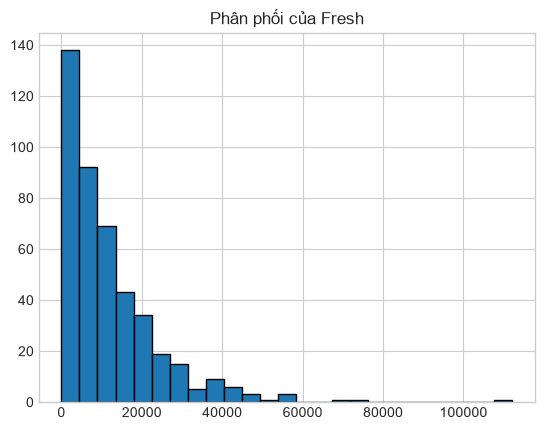

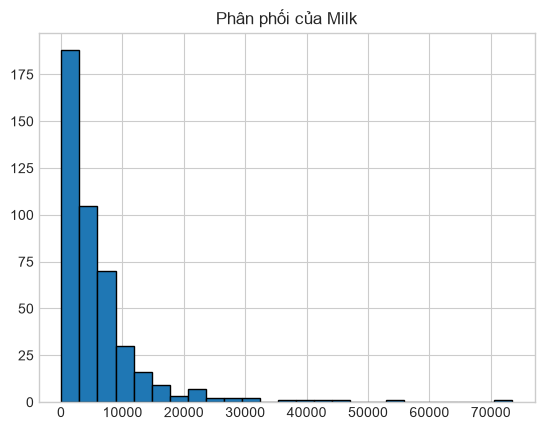

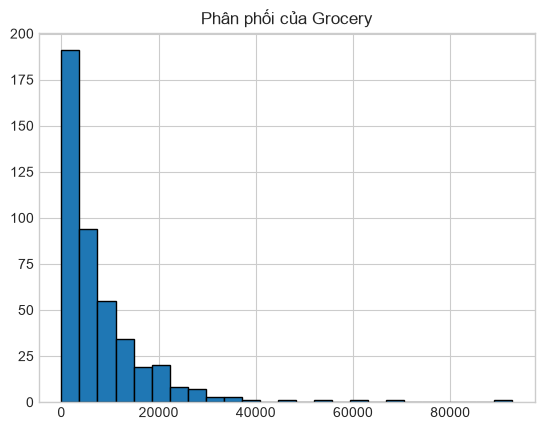

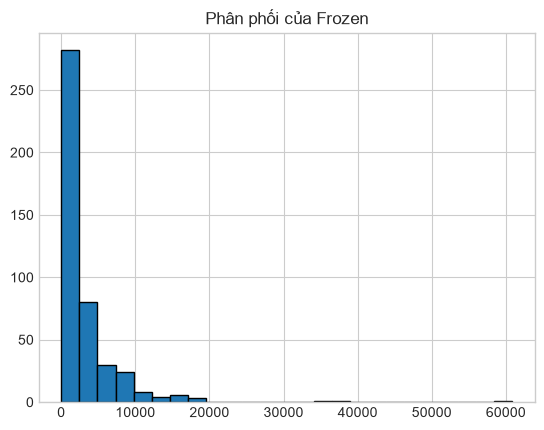

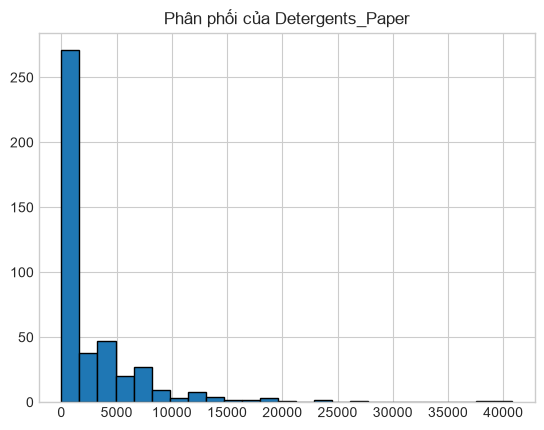

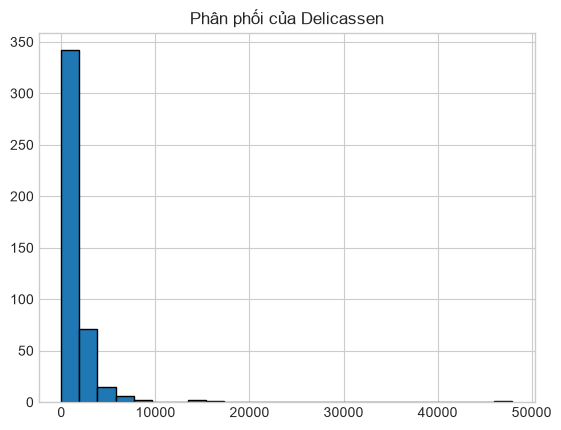

In [5]:
features = X_raw.columns.tolist()
for feature in features:
    plt.figure()
    plt.hist(X_raw[feature],edgecolor ='black', linewidth=1, bins =25)
    plt.title(f'Phân phối của {feature}')
    

- Nhận xét: Tất cả các feature đều có dữ liệu lệch phải, dữ liệu tập trung lớn ở phần đầu và giảm mạnh về sau, tồn tại các outlier nằm rất xa phần dữ liệu tập trung nhiều nhất các điểm này có thể coi là khách hàng vip của nhà phân phối. 
=> Cho thấy phần lớn khách hàng là khách hàng bình thường với nhu cầu bình thường và chỉ tồn tại số ít khách mua rất nhiều sản phẩm.

In [6]:
desc = X_raw.describe().T
std = desc['std']
print(std)

Fresh              12,647.33
Milk                7,380.38
Grocery             9,503.16
Frozen              4,854.67
Detergents_Paper    4,767.85
Delicassen          2,820.11
Name: std, dtype: float64


- nhận xét: ta thấy độ lệch chuẩn của các thuộc tính khá lớn. Độ lệch chuẩn của Fresh, Milk, Grocery lớn nhất đáng kể so với các cái còn lại nên khi tính khoảng cách các giá trị này có thể cách xa nhau hơn làm nó ảnh hưởng đến độ lớn của khoảng cách.

                  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Fresh              1.00  0.10    -0.01    0.35             -0.10        0.24
Milk               0.10  1.00     0.73    0.12              0.66        0.41
Grocery           -0.01  0.73     1.00   -0.04              0.92        0.21
Frozen             0.35  0.12    -0.04    1.00             -0.13        0.39
Detergents_Paper  -0.10  0.66     0.92   -0.13              1.00        0.07
Delicassen         0.24  0.41     0.21    0.39              0.07        1.00


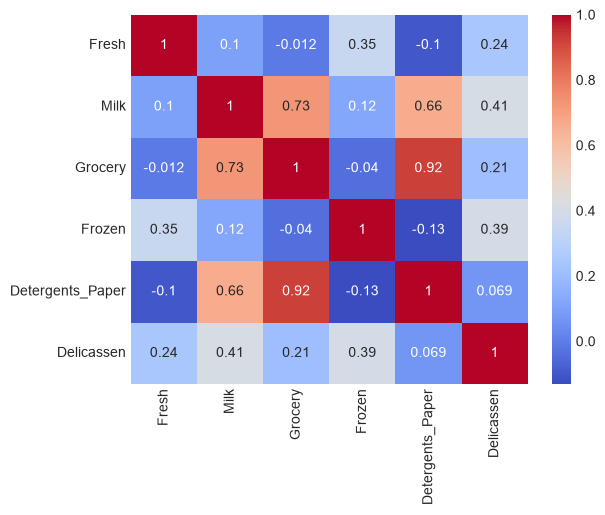

In [7]:
corr = X_raw.corr()
print(corr)
sns.heatmap(corr,cmap ='coolwarm', annot = True)
plt.show()


- Dựa vào biểu đồ ma trận tương quan, có thể thấy Milk, Grocery và Detergents_paper có tương quan dương khá mạnh nên khi thấy cụm tập trung nhiều cái này thì có thể giải thích được là nhóm hàng tạp hóa hay tên gì đó. 
- Frozen và Delicassen có tương quan dương vừa phải nên có thể phân biệt được 1 nhóm nhỏ hay nhóm đặt biệt. 
- Fresh hầu như không tương quan mạnh với bất kì loại đồ nào nên khi thấy 1 cụm thì có thể nói là nhóm mua hàng tươi sống hay gì đó.

#### Tổng kết: 
- Đa số các thuộc tính trong data đều có phân phối lệch phải, độ lệch chuẩn lớn đáng kể so của Fresh, Milk, Grocery làm chênh lệch khoảng cách với các thuộc tính còn lại. 
- Fresh, Milk, Grocery có mức biến thiên đáng kể so với các thuộc tính còn lại riêng Detergents_Paper cũng đánh chú ý vì nó tương quan dương mạnh với Grocery và Milk nên tuy độ lệch chuẩn không cao bằng mấy cái khác nhưng có thể biến thiên lớn khi Grocery hoặc Milk biến thiên. Về mặt thang đo thì các thuộc tính dùng chung thang đo và độ lớn giá trị tương đối cân bằng.
- Có mối quan hệ đánh chủ ý là giữa Grocery, Milk và Detergents_Paper vì chúng có tương quan dương mạnh với nhau nên khi có cụm gần nhau thì có thể xem đây là 1 nhóm khách hàng.
- Quan sát thấy dữ liệu lệch phải và các outlier là quan trọng vì các outlier là các khách hàng lớn nên em nghĩ sẽ dùng log1p để điều chỉnh lại phân phối(vì dữ liệu lệch phải và không âm) sau đó dùng RobustScaler để scale lại (vì RobustScaler ít bị ảnh hưởng bởi outlier) sau đó có thể dùng Kmeans để phân nhóm khách hàng (vì lúc này sự chênh lệch về khoảng cách giữa 2 feature đã được đưa về cùng tỉ lệ)

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

##### Trước khi quyết định sửa dụng Scaler nào thì em sẽ xem phân phối của các thuốc tính sau khi dùng log1p xem có gần phân phối chuẩn không.

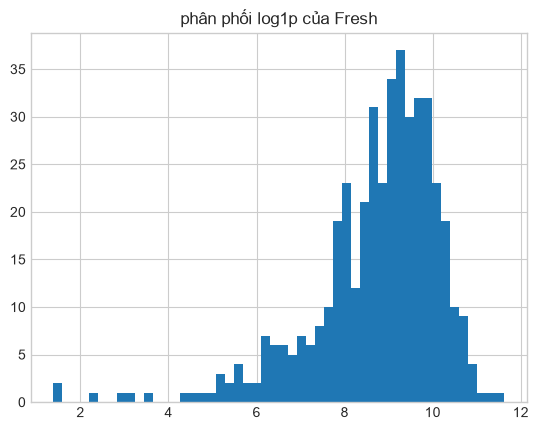

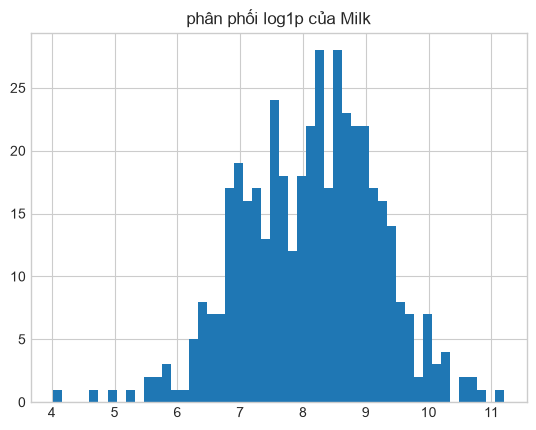

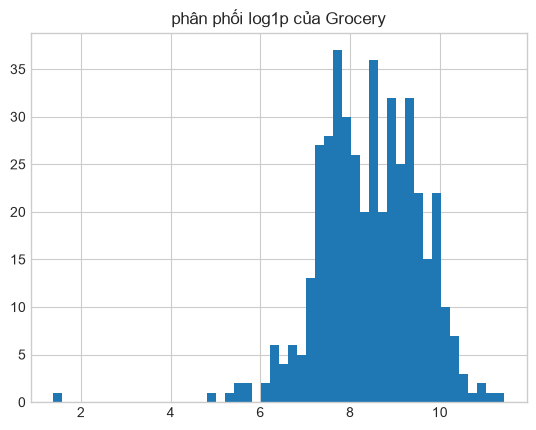

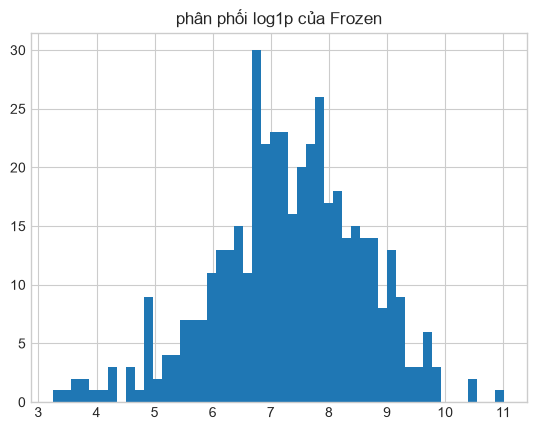

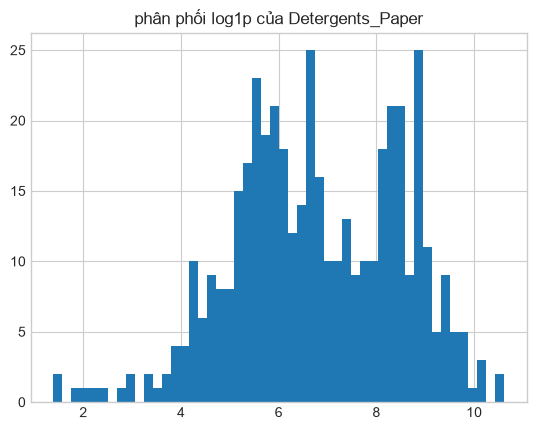

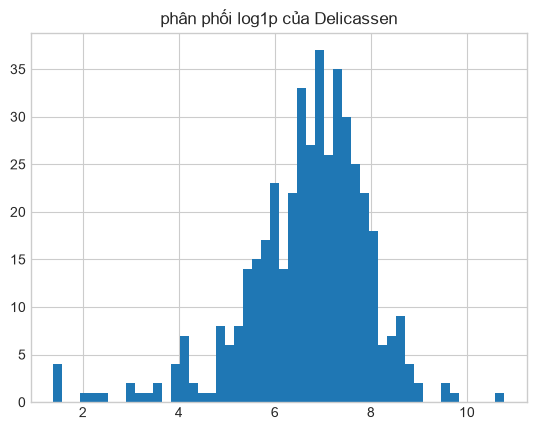

In [8]:
X_lg = np.log1p(X_raw)
for feature in features:
    plt.figure()
    plt.hist(X_lg[feature],bins = 50)
    plt.title(f'phân phối log1p của {feature}')
    plt.show()

- Nhận thấy dữ liệu phân bố tương đối chuẩn và có nhiều outlier. Mà trong bài toán này em muốn giữ lại outlier và để mô hình ít bị ảnh hương bởi outlier và giữ quan hệ thứ tự và cấu trúc tương đối nên em sẽ sử dụng RobustScaler.

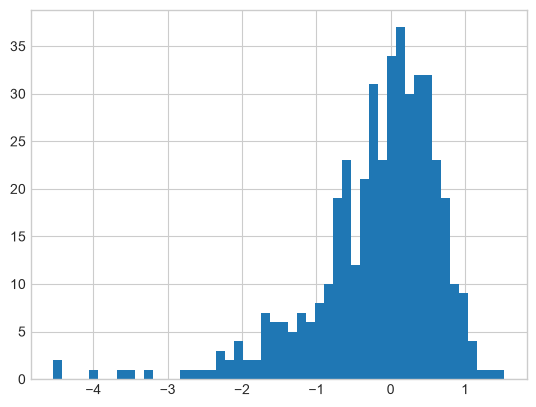

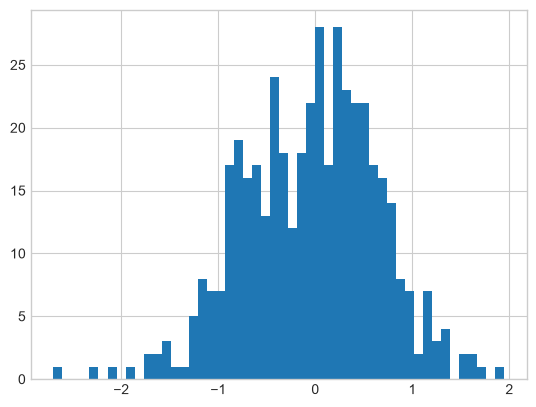

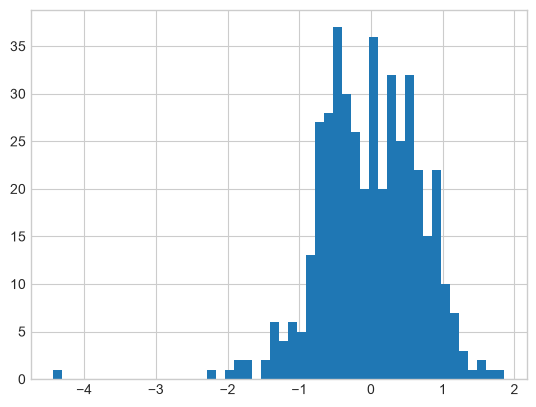

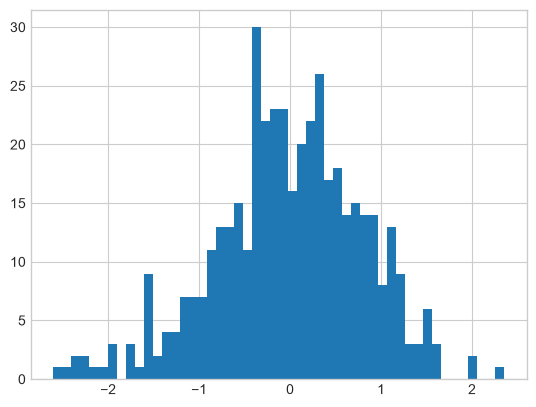

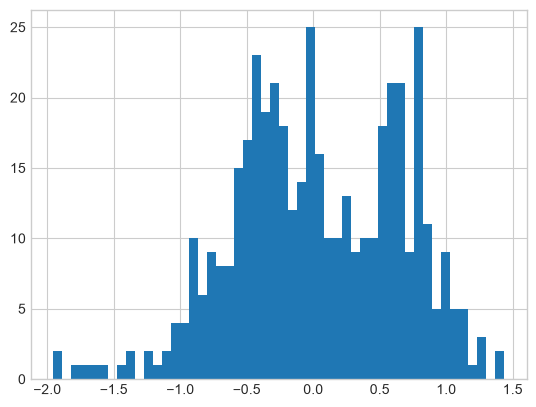

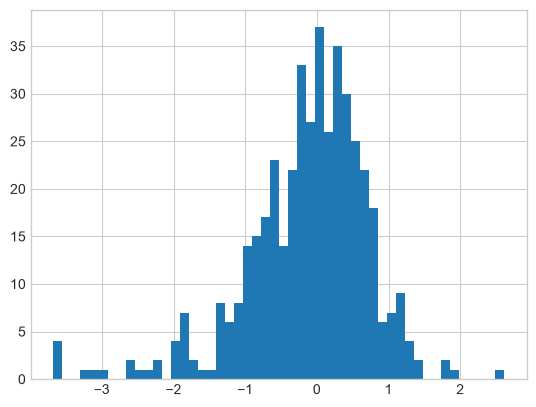

In [9]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
X_model = RobustScaler().fit_transform(X_lg)
df_model = pd.DataFrame(X_model, columns = X_lg.columns)
for feature in features:
    plt.figure()
    plt.hist(df_model[feature], bins = 50)
    plt.show()


- dữ liệu sau khi dùng RobustScaler để scale lại thì giá trị của mọi thuộc tính đều đưa về trung vị 0 với IQR là 1 và cấu trúc dữ liệu tương ứng, giảm ảnh hưởng về khác biệt scale khi tính khoảng cách.

In [10]:
df_model.describe().T


,count,mean,std,min,25%,50%,75%,max
Fresh,440.00,-0.19,0.87,-4.54,-0.59,-0.00,0.41,1.53
Milk,440.00,-0.05,0.70,-2.70,-0.56,-0.00,0.44,1.95
Grocery,440.00,-0.02,0.70,-4.43,-0.50,0.00,0.50,1.86
Frozen,440.00,-0.02,0.82,-2.60,-0.46,0.00,0.54,2.35
Detergents_Paper,440.00,0.03,0.63,-1.95,-0.42,0.00,0.58,1.44
Delicassen,440.00,-0.14,0.87,-3.68,-0.58,0.00,0.42,2.62


- dữ liệu có chênh lệch độ lệch chuẩn nhỏ hơn giúp giảm ảnh hưởng của chênh lệch lớn khi tính khoảng cách.


#### Tổng kết:
- với dữ liệu trên đẻ xử lí skew, outlier và khác biệt scale tôi đã dùng log1p giúp giảm lệch phải và làm phân phối gần đối xứng hơn, tiếp theo dùng RobustScaler để scale dữ liệu giúp giảm sự chênh lệch độ lệch chuẩn giữa các thuộc tính giúp tính toán khoảng cách không bị phụ thuộc nhiều vào các thuộc tính có độ lệch chuẩn lớn.
-  ma trận dùng để fit model là ma trận sau khi thực hiện log1p và scale bằng RobustScaler là X_model vì đây là dữ liệu đã được xử lí, được đưa về dạng gần phân phối chuẩn và các thuộc tính có độ lệch chuẩn chênh lệch thấp không còn làm tăng lợi thế của 1 thuộc tính nào đó khi có độ lệch chuẩn cao hơn và góp nhiều ý nghĩa hơn vào phần tính khoảng cách.
-  trade-off của lựa chọn preprocessing là đánh đổi làm méo thang đo dữ liệu so với dữ liệu gốc để dưa dữ liệu về phân phối tốt hơn.
-  dữ liệu X_raw vấn được bảo toàn để dùng lại.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [11]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
results = []
for k in range(2,20):
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_model)
    noise = np.sum(labels ==-1)
    mask = labels != -1
    silh = silhouette_score(X_model[mask], labels[mask])
    dav = davies_bouldin_score(X_model[mask], labels[mask])
    result = {'N_clusters':k, 'Noise_count': noise,'Inertia': model.inertia_,'Silhouette':silh, 'DaviesBouldin': dav}
    results.append(result)

kmeans_df = pd.DataFrame(results)
kmeans_df[['N_clusters', 'Noise_count','Inertia','Silhouette','DaviesBouldin']]




,N_clusters,Noise_count,Inertia,Silhouette,DaviesBouldin
0,2,0,"1,173.64",0.25,1.55
1,3,0,953.93,0.24,1.32
2,4,0,849.68,0.20,1.38
3,5,0,779.02,0.19,1.44
4,6,0,714.74,0.20,1.37
5,7,0,658.74,0.20,1.34
6,8,0,620.72,0.19,1.36
7,9,0,584.69,0.19,1.34
8,10,0,554.66,0.20,1.30
9,11,0,533.18,0.19,1.35


- Dựa vào bảng thông số ta thấy Inertia khi N_clusters từ 2 lên 3 là giảm nhiều nhất sau đó lượng giảm nhỏ lại cùng với đó Silhouette có giá trị là 0.24 cao hơn so với các cái khác chỉ xếp sau N_cluster = 2 tuy cho thấy sự trùng lặp overlap nhưng nó đã tốt hơn so với những giá trị khác và DaviesBouldin tại N_clusters = 3 có giá trị 1.32 thấp hơn đa phần các giá trị khác nên ở bài toán này chọn N_clusters = 3 cho thấy dữ liệu chia làm 3 cụm. 

In [12]:
model = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
labels = model.fit_predict(X_model)
noise = np.sum(labels ==-1)
mask = labels != -1
cluster_size = {}
for i in labels[mask]:
    if i in cluster_size:
        cluster_size[i]+=1
    else:
        cluster_size[i]=0
print(cluster_size)

{np.int32(0): 150, np.int32(1): 208, np.int32(2): 79}


- model có tập data dùng để khai phá là X_model với các tham số đầu vào là số lần lặp để cập nhật tâm là n_init = 20 và số cụm k được chạy thử từ 2 đến 19
- Số cụm tạo ra là 3 cụm, với cụm thứ nhất có 150 điểm, cụm thứ 2 có 208 điểm, cụm thứ 3 có 79 điểm.

In [13]:
results = []
for k in range(2,20):
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels_hierarchical = model.fit_predict(X_model)
    noise = np.sum(labels_hierarchical == -1)
    mask = labels_hierarchical != -1
    silh = silhouette_score(X_model[mask], labels_hierarchical[mask])
    dav = davies_bouldin_score(X_model[mask], labels_hierarchical[mask])
    result = {'N_clusters':k, 'Noise_count': noise,'Silhouette':silh, 'DaviesBouldin': dav}
    results.append(result)

hierarchical_df = pd.DataFrame(results)
hierarchical_df[['N_clusters', 'Noise_count','Silhouette','DaviesBouldin']]


,N_clusters,Noise_count,Silhouette,DaviesBouldin
0,2,0,0.23,1.79
1,3,0,0.24,1.39
2,4,0,0.16,1.59
3,5,0,0.14,1.59
4,6,0,0.15,1.59
5,7,0,0.16,1.51
6,8,0,0.16,1.43
7,9,0,0.17,1.36
8,10,0,0.14,1.42
9,11,0,0.15,1.41


- Với Hierarchical Clustering, tập data dùng để khai phá vẫn là X_model. Em dùng AgglomerativeClustering với linkage='ward' và thử số cụm k từ 2 đến 19 để so sánh với KMeans trên cùng một dữ liệu đầu vào.
- Hierarchical Clustering không có inertia như KMeans và cũng không gán nhãn noise, nên evidence chính để đánh giá là Silhouette, DaviesBouldin và Cluster_size. Cấu hình tốt hơn là cấu hình có Silhouette tương đối cao, DaviesBouldin thấp và kích thước cụm không quá lệch.
- Dựa vào bảng kết quả, em sẽ so sánh các giá trị k của Hierarchical Clustering với KMeans. Nếu Hierarchical cho metric tương đương nhưng cluster size khó diễn giải hơn, em sẽ ưu tiên KMeans vì mô hình này đơn giản, dễ kiểm soát số cụm và dễ dùng để profile khách hàng. Nếu Hierarchical tạo cụm cân bằng hơn hoặc metric tốt hơn rõ ràng, cấu hình đó có thể được giữ lại để đánh giá tiếp ở phần E.

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [14]:
# So sánh trực tiếp 2 candidate chính: KMeans k=3 và Hierarchical k=3
candidate_results = []

model_kmeans_final = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
labels_kmeans_final = model_kmeans_final.fit_predict(X_model)

model_hierarchical_3 = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hierarchical_3 = model_hierarchical_3.fit_predict(X_model)

candidates = [
    ('KMeans', labels_kmeans_final),
    ('Hierarchical', labels_hierarchical_3)
]

for model_name, candidate_labels in candidates:
    noise = np.sum(candidate_labels == -1)
    mask = candidate_labels != -1
    silh = silhouette_score(X_model[mask], candidate_labels[mask])
    dav = davies_bouldin_score(X_model[mask], candidate_labels[mask])
    cluster_size = pd.Series(candidate_labels[mask]).value_counts().sort_index().to_dict()
    result = {
        'Model': model_name,
        'N_clusters': 3,
        'Noise_count': noise,
        'Silhouette': silh,
        'DaviesBouldin': dav,
        'Cluster_size': cluster_size
    }
    candidate_results.append(result)

candidate_df = pd.DataFrame(candidate_results)
candidate_df[['Model', 'N_clusters', 'Noise_count', 'Silhouette', 'DaviesBouldin', 'Cluster_size']]


,Model,N_clusters,Noise_count,Silhouette,DaviesBouldin,Cluster_size
0,KMeans,3,0,0.24,1.32,"{0: 151, 1: 209, 2: 80}"
1,Hierarchical,3,0,0.24,1.39,"{0: 265, 1: 126, 2: 49}"


- so sánh trực tiếp hai candidate chính là KMeans k=3 và Hierarchical Clustering k=3 trên cùng một matrix X_model. Các chỉ số được dùng là Silhouette, DaviesBouldin và kích thước cụm thì Kmeans cho DavisBouldin tốt hơn khi giá trị của nó là 1.32 nhỏ hơn 1.39 của Hierarchical và phân cụm cũng tốt hơn khi phần bố đều hơn.


In [15]:
# Stability check: đổi random_state của KMeans k=3 và so nhãn với model gốc bằng ARI
labels_final = labels_kmeans_final
stability_results = []

for seed in [0, 1, 2, 3, 4, 5, 10, 20, 42, 100]:
    model = KMeans(n_clusters=3, n_init=20, random_state=seed)
    labels_seed = model.fit_predict(X_model)
    ari = adjusted_rand_score(labels_final, labels_seed)
    silh = silhouette_score(X_model, labels_seed)
    dav = davies_bouldin_score(X_model, labels_seed)
    cluster_size = pd.Series(labels_seed).value_counts().sort_index().to_dict()
    result = {
        'Seed': seed,
        'ARI_vs_final': ari,
        'Silhouette': silh,
        'DaviesBouldin': dav,
        'Cluster_size': cluster_size
    }
    stability_results.append(result)

stability_df = pd.DataFrame(stability_results)
stability_df[['Seed', 'ARI_vs_final', 'Silhouette', 'DaviesBouldin', 'Cluster_size']]


,Seed,ARI_vs_final,Silhouette,DaviesBouldin,Cluster_size
0,0,0.99,0.24,1.32,"{0: 209, 1: 149, 2: 82}"
1,1,1.00,0.24,1.32,"{0: 151, 1: 80, 2: 209}"
2,2,1.00,0.24,1.32,"{0: 209, 1: 151, 2: 80}"
3,3,0.99,0.24,1.32,"{0: 149, 1: 209, 2: 82}"
4,4,0.99,0.24,1.32,"{0: 149, 1: 82, 2: 209}"
5,5,0.99,0.24,1.32,"{0: 209, 1: 82, 2: 149}"
6,10,0.99,0.24,1.32,"{0: 149, 1: 209, 2: 82}"
7,20,0.99,0.24,1.32,"{0: 149, 1: 209, 2: 82}"
8,42,1.00,0.24,1.32,"{0: 151, 1: 209, 2: 80}"
9,100,0.99,0.24,1.32,"{0: 209, 1: 149, 2: 82}"


- giá trị của các thông số gần như không đổi với các randomseed khác nhau nên model không đổi khi thay đổi thông số.

#### Kết luận phần E

- Model cuối được chọn là KMeans với n_clusters=3, n_init=20, random_state=RANDOM_STATE, fit trên X_model sau log1p và RobustScaler.
- Evidence mạnh nhất là k=3 có điểm cân bằng giữa elbow/inertia ở phần D, Silhouette tương đối tốt so với các k khác, DaviesBouldin không quá cao và cluster size không bị quá nhỏ để khó dùng để đánh giá.
- Stability được kiểm tra bằng cách đổi nhiều random_state và dùng ARI để so với nhãn cuối và kết quả cho ra ổn định với các giá trị là 1 và 0.99
- Điều em vẫn chưa chắc chắn là các metric nội bộ chưa thật sự cao, nghĩa là ranh giới giữa các cụm có thể còn overlap. Vì vậy cần kiểm tra thêm bằng profile cụm, Channel/Region hoặc dữ liệu business như lợi nhuận.


# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


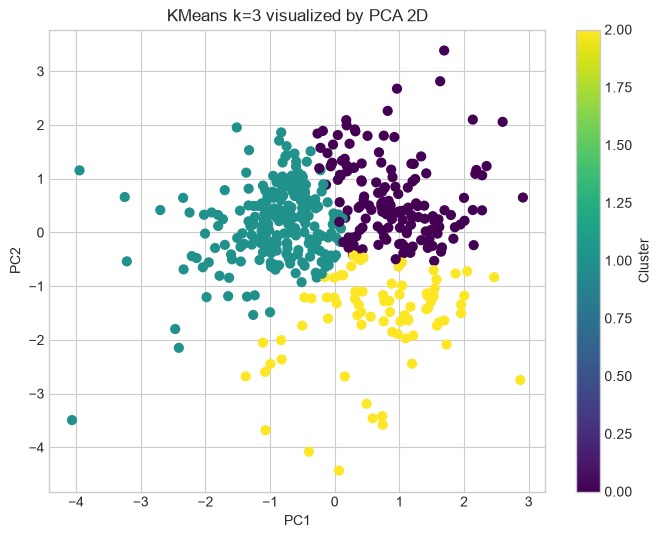

In [16]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=labels_final, cmap='viridis', s=40)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans k=3 visualized by PCA 2D')
plt.colorbar(label='Cluster')
plt.show()


- Biểu đồ PCA 2D giúp quan sát sơ bộ cách các cụm KMeans phân bố sau khi chiếu dữ liệu 6 chiều xuống 2 chiều. Có thể thấy các cụm có một mức độ tách biệt nhất định nhưng vẫn còn overlap, phù hợp với Silhouette chưa quá cao ở phần đánh giá. Tuy nhiên, PCA 2D chỉ là phép chiếu để giao tiếp kết quả, không phải bằng chứng duy nhất cho chất lượng clustering vì một phần thông tin từ 6 feature ban đầu đã bị mất khi giảm xuống 2 chiều.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [17]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
print(profile)


            Fresh     Milk   Grocery   Frozen  Detergents_Paper  Delicassen
cluster                                                                    
0       11,908.00 7,108.00  9,965.00 1,840.00          3,378.00    1,970.00
1        9,784.00 1,601.00  2,147.00 2,181.00            274.00      686.00
2        1,190.00 6,300.50 10,431.00   393.00          4,181.50      414.00


Chia 3 nhóm là:
- Nhóm chi tiêu tổng hợp: dựa trên Fresh, Milk, Grocery, Detergents_Paper, Delicassen (cluster 0) với Fresh = 11,908, Milk = 7,108, Grocery = 9,965, Detergents_Paper = 3,378, Delicassen = 1,970. Có thể thử chương trình chăm sóc/bundle đa danh mục cho nhóm này, ví dụ gói kết hợp Fresh + Milk + Grocery hoặc ưu đãi theo tổng giá trị đơn hàng để tăng retention và basket size. Trước khi biến hypothesis này thành quyết định, cần thêm dữ liệu về lợi nhuận theo khách hàng, tần suất mua, giá trị đơn hàng trung bình, chi phí phục vụ và phản hồi của nhóm này với các chương trình ưu đãi trước đó.
- Nhóm tươi sống: dựa trên Fresh (cluster 1) có Fresh = 9,784 khá cao nhưng Milk = 1,601, Grocery = 2,147, Detergents_Paper = 274, Delicassen = 686 thấp. Có thể ưu tiên chính sách giao hàng nhanh, đảm bảo tồn kho hàng tươi sống, hoặc thử ưu đãi bổ sung Frozen/Delicassen để tăng cross-sell. Trước khi quyết định triển khai, cần thêm dữ liệu về tần suất đặt hàng Fresh, thời điểm đặt hàng, yêu cầu giao hàng, tỷ lệ hủy/hoàn đơn, biên lợi nhuận của nhóm Fresh và khả năng nhóm này phản hồi với các offer cross-sell.
- Nhóm tạp hóa: dựa trên Grocery, Milk, Detergents_Paper (cluster 2) Grocery = 10,431, Milk = 6,300.5, Detergents_Paper = 4,181.5 cao và Fresh = 1,190, Frozen = 393, Delicassen = 414 thấp. Có thể thử bundle Grocery + Milk + Detergents_Paper, chính sách chiết khấu theo số lượng, hoặc chương trình đặt hàng định kỳ cho nhóm hàng tiêu dùng nhanh. Trước khi biến hypothesis này thành quyết định, cần thêm dữ liệu về tần suất mua lặp lại, độ nhạy với chiết khấu, lợi nhuận từng nhóm sản phẩm, tồn kho, lịch sử phản hồi campaign và khả năng tăng doanh thu thực sự từ bundle.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

                                                                     Bài làm:
Nên dùng segmentation này ở mức thử nghiệm giới hạn, chưa nên áp dụng rộng ngay. Phân tích cho thấy dữ liệu chi tiêu có thể chia thành 3 nhóm khách hàng có hành vi khác nhau, nhưng các metric nội bộ như Silhouette chưa quá cao nên ranh giới giữa các cụm vẫn có thể overlap.
Model cuối được chọn là KMeans với k=3, fit trên dữ liệu đã xử lý bằng log1p và RobustScaler. log1p giúp giảm lệch phải của dữ liệu chi tiêu, còn RobustScaler giúp giảm ảnh hưởng của outlier. K=3 được chọn vì cân bằng giữa inertia/elbow, Silhouette, Davies-Bouldin và kích thước cụm tương đối hợp lý.
Hai insight quan trọng là: cluster 0 là nhóm chi tiêu tổng hợp, mua khá cao ở nhiều danh mục như Fresh, Milk, Grocery và Delicassen; cluster 2 là nhóm tạp hóa, nổi bật ở Grocery, Milk và Detergents_Paper nhưng thấp ở Fresh/Frozen. Cluster 1 thiên về Fresh, phù hợp với nhóm khách hàng tập trung vào hàng tươi sống.
Action nên thử trước là campaign bundle theo cụm: Fresh + Milk + Grocery cho nhóm tổng hợp, và Grocery + Milk + Detergents_Paper cho nhóm tạp hóa. Đánh giá bằng doanh thu tăng thêm, basket size, tần suất mua lại và tỷ lệ phản hồi campaign.
Giới hạn lớn nhất là dữ liệu chỉ có chi tiêu hằng năm, chưa có lợi nhuận, thời gian mua, tần suất, chi phí phục vụ và phản hồi marketing.

## Checklist trước khi nộp

- [x] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [x] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [x] Có ≥2 thuật toán và quyết định model có evidence.
- [x] Có kiểm tra stability/robustness và diễn giải kết quả.
- [x] Không đọc PCA 2D như bằng chứng duy nhất.
- [x] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [x] Có giới hạn và kết luận business rõ ràng.
